In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/MU projekat/konacni.csv')

In [ ]:
print(data.head())
print(data.info())
print(data.describe())


     Month    Occupation  Annual_Income  Num_Bank_Accounts  Num_Credit_Card  \
0  January     scientist      -0.798355                  3        -0.487832   
1  January        lawyer      -0.241556                  0         0.278399   
2  January  entrepreneur       0.731299                  1        -0.487832   
3  January        doctor      -0.918716                  6         0.278399   
4  January     scientist      -0.793470                 10         0.540550   

   Interest_Rate  Num_of_Loan  Delay_from_due_date  Num_of_Delayed_Payment  \
0      -1.635291     0.285473                    3               -0.611065   
1      -0.432666    -0.330293                   12               -0.312104   
2      -0.777158    -0.890099                   24               -1.974150   
3       0.568194     0.887536                   21                0.970670   
4       0.924647     0.887536                   43                0.768778   

   Changed_Credit_Limit  ...  Age Auto Loan  Credit-Buil

In [ ]:
print(data.isnull().sum())

Month                          0
Occupation                  6927
Annual_Income                  0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     4409
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
Age                            0
Auto Loan                      0
Credit-Builder Loan            0
Personal Loan                  0
Home Equity Loan               0
Not Specified                  0
Mortgage Loan                  0
Student Loan                   0
Debt Consolidation Loan        0
Payday Loa

In [ ]:
print(data['Credit_Score'])

0            Good
1        Standard
2            Poor
3            Poor
4        Standard
           ...   
98433        Poor
98434    Standard
98435        Poor
98436    Standard
98437        Poor
Name: Credit_Score, Length: 98438, dtype: object


In [ ]:
data.drop('Credit_Score', axis=1, inplace=True)

month_mode = data['Occupation'].mode()[0]
data['Occupation'] = data['Occupation'].fillna(month_mode)

amount_median = data['Amount_invested_monthly'].median()
data['Amount_invested_monthly'] = data['Amount_invested_monthly'].fillna(amount_median)

# Label encoding za sve kategoričke varijable
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in data.select_dtypes(include=['object', 'category']).columns:
    data[col] = encoder.fit_transform(data[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(data)

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(3.0, 5.0, 0.5)
min_samples_values = range(5, 10)

best_combination = None
best_score = -1

print("Testing combinations of eps and min_samples...")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(data)

        # Broj klastera (ignorišemo šum)
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        num_noise = list(labels).count(-1)

        # Procenat šuma
        noise_percentage = num_noise / len(data) * 100

        # Silhouette Score (samo ako postoje barem 2 klastera)
        if num_clusters > 1:
            non_noise_mask = labels != -1
            silhouette_avg = silhouette_score(data[non_noise_mask], labels[non_noise_mask])
        else:
            silhouette_avg = float('-inf')  # Negativna vrijednost za loše kombinacije

        # Evaluacija: Bolji Silhouette Score i manji procenat šuma
        if silhouette_avg > best_score and noise_percentage < 20:
            best_score = silhouette_avg
            best_combination = (eps, min_samples, num_clusters, noise_percentage)

        print(f"eps={eps:.1f}, min_samples={min_samples} -> "
              f"Klasteri: {num_clusters}, Šum: {num_noise} ({noise_percentage:.2f}%), "
              f"Silhouette Score: {silhouette_avg:.3f}")

# Najbolja kombinacija
if best_combination:
    eps, min_samples, num_clusters, noise_percentage = best_combination
    print(f"\nNajbolja kombinacija: eps={eps:.1f}, min_samples={min_samples}, "
          f"Klasteri: {num_clusters}, Šum: {noise_percentage:.2f}%, "
          f"Silhouette Score: {best_score:.3f}")
else:
    print("\nNijedna kombinacija nije zadovoljila kriterije.")


Testing combinations of eps and min_samples...
eps=3.0, min_samples=5 -> Klasteri: 1608, Šum: 26875 (27.30%), Silhouette Score: -0.255
eps=3.0, min_samples=6 -> Klasteri: 1235, Šum: 32866 (33.39%), Silhouette Score: -0.247
eps=3.0, min_samples=7 -> Klasteri: 882, Šum: 39377 (40.00%), Silhouette Score: -0.242
eps=3.0, min_samples=8 -> Klasteri: 593, Šum: 45848 (46.58%), Silhouette Score: -0.231
eps=3.0, min_samples=9 -> Klasteri: 429, Šum: 51149 (51.96%), Silhouette Score: -0.216
eps=3.5, min_samples=5 -> Klasteri: 135, Šum: 9210 (9.36%), Silhouette Score: -0.234
eps=3.5, min_samples=6 -> Klasteri: 101, Šum: 10160 (10.32%), Silhouette Score: -0.220
eps=3.5, min_samples=7 -> Klasteri: 59, Šum: 11348 (11.53%), Silhouette Score: -0.202
eps=3.5, min_samples=8 -> Klasteri: 45, Šum: 12532 (12.73%), Silhouette Score: -0.199
eps=3.5, min_samples=9 -> Klasteri: 20, Šum: 13889 (14.11%), Silhouette Score: -0.156
eps=4.0, min_samples=5 -> Klasteri: 16, Šum: 3562 (3.62%), Silhouette Score: -0.036
ep

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


pca = PCA(n_components=0.9)
data = pca.fit_transform(data)

eps_values = np.arange(3.0, 5.0, 0.5)
min_samples_values = range(5, 10)

best_combination = None
best_score = -1

print("Testing combinations of eps and min_samples...")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(data)

        # Broj klastera (ignorišemo šum)
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        num_noise = list(labels).count(-1)

        # Procenat šuma
        noise_percentage = num_noise / len(data) * 100

        # Silhouette Score (samo ako postoje barem 2 klastera)
        if num_clusters > 1:
            non_noise_mask = labels != -1
            silhouette_avg = silhouette_score(data[non_noise_mask], labels[non_noise_mask])
        else:
            silhouette_avg = float('-inf')  # Negativna vrijednost za loše kombinacije

        # Evaluacija: Bolji Silhouette Score i manji procenat šuma
        if silhouette_avg > best_score and noise_percentage < 20:
            best_score = silhouette_avg
            best_combination = (eps, min_samples, num_clusters, noise_percentage)

        print(f"eps={eps:.1f}, min_samples={min_samples} -> "
              f"Klasteri: {num_clusters}, Šum: {num_noise} ({noise_percentage:.2f}%), "
              f"Silhouette Score: {silhouette_avg:.3f}")

# Najbolja kombinacija
if best_combination:
    eps, min_samples, num_clusters, noise_percentage = best_combination
    print(f"\nNajbolja kombinacija: eps={eps:.1f}, min_samples={min_samples}, "
          f"Klasteri: {num_clusters}, Šum: {noise_percentage:.2f}%, "
          f"Silhouette Score: {best_score:.3f}")
else:
    print("\nNijedna kombinacija nije zadovoljila kriterije.")



Testing combinations of eps and min_samples...
eps=3.0, min_samples=5 -> Klasteri: 207, Šum: 11221 (11.40%), Silhouette Score: -0.272
eps=3.0, min_samples=6 -> Klasteri: 150, Šum: 12679 (12.88%), Silhouette Score: -0.262
eps=3.0, min_samples=7 -> Klasteri: 101, Šum: 14154 (14.38%), Silhouette Score: -0.249
eps=3.0, min_samples=8 -> Klasteri: 57, Šum: 15690 (15.94%), Silhouette Score: -0.228
eps=3.0, min_samples=9 -> Klasteri: 25, Šum: 17102 (17.37%), Silhouette Score: -0.184
eps=3.5, min_samples=5 -> Klasteri: 23, Šum: 3980 (4.04%), Silhouette Score: -0.095
eps=3.5, min_samples=6 -> Klasteri: 19, Šum: 4224 (4.29%), Silhouette Score: -0.073
eps=3.5, min_samples=7 -> Klasteri: 8, Šum: 4500 (4.57%), Silhouette Score: 0.003
eps=3.5, min_samples=8 -> Klasteri: 7, Šum: 4721 (4.80%), Silhouette Score: -0.025
eps=3.5, min_samples=9 -> Klasteri: 3, Šum: 4986 (5.07%), Silhouette Score: 0.027
eps=4.0, min_samples=5 -> Klasteri: 12, Šum: 1496 (1.52%), Silhouette Score: 0.116
eps=4.0, min_samples=6

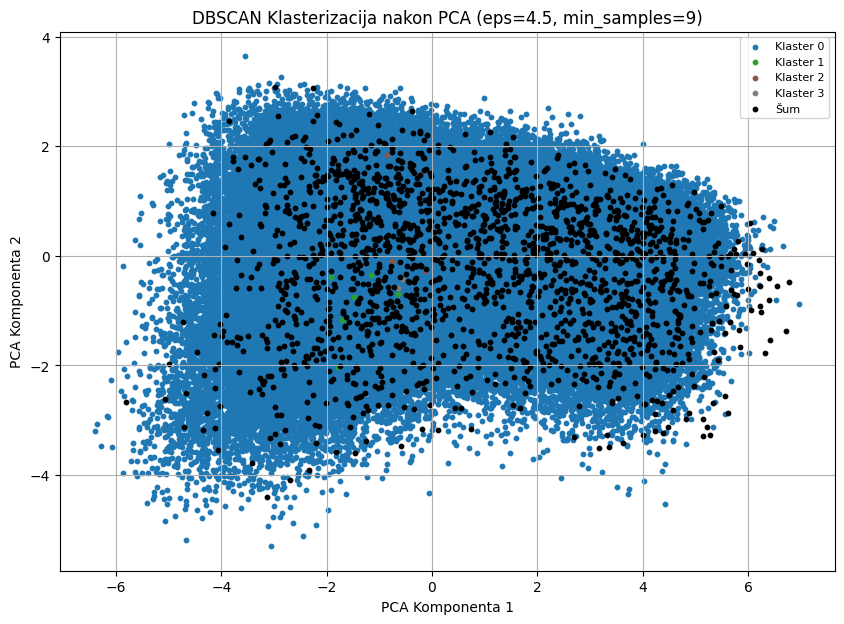

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Primjena najboljih parametara
dbscan = DBSCAN(eps=4, min_samples=8)
labels = dbscan.fit_predict(data)

# Boje za klastere i šum
unique_labels = set(labels)
colors = [plt.cm.tab10(each) for each in np.linspace(0, 1, len(unique_labels))]

# Kreiranje scatter plot-a
plt.figure(figsize=(10, 7))
for label, color in zip(unique_labels, colors):
    if label == -1:  # Šum
        color = [0, 0, 0, 1]  # Crna boja za šum
    mask = labels == label
    plt.scatter(data[mask, 0], data[mask, 1], c=[color], label=f'Klaster {label}' if label != -1 else 'Šum', s=10)

# Dodavanje legendi i oznaka
plt.title('DBSCAN Klasterizacija nakon PCA (eps=4.5, min_samples=9)')
plt.xlabel('PCA Komponenta 1')
plt.ylabel('PCA Komponenta 2')
plt.legend(loc='best', fontsize=8)
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import davies_bouldin_score

# DBSCAN sa najboljim parametrima
dbscan = DBSCAN(eps=4.5, min_samples=9)
labels = dbscan.fit_predict(data)

# Filtriranje šuma (tačke sa labelom -1 se ignorišu za DBI)
non_noise_mask = labels != -1
if len(set(labels[non_noise_mask])) > 1:  # Provera da li ima više od jednog klastera
    dbi = davies_bouldin_score(data[non_noise_mask], labels[non_noise_mask])
    print(f"Davies-Bouldin Index: {dbi:.3f}")
else:
    print("Davies-Bouldin Index nije moguće izračunati jer postoji samo jedan klaster.")


Davies-Bouldin Index: 0.823


In [ ]:
from sklearn.metrics import davies_bouldin_score

# DBSCAN sa najboljim parametrima
dbscan = DBSCAN(eps=4, min_samples=8)
labels = dbscan.fit_predict(data)

# Filtriranje šuma (tačke sa labelom -1 se ignorišu za DBI)
non_noise_mask = labels != -1
if len(set(labels[non_noise_mask])) > 1:  # Provera da li ima više od jednog klastera
    dbi = davies_bouldin_score(data[non_noise_mask], labels[non_noise_mask])
    print(f"Davies-Bouldin Index: {dbi:.3f}")
else:
    print("Davies-Bouldin Index nije moguće izračunati jer postoji samo jedan klaster.")


Davies-Bouldin Index: 1.262


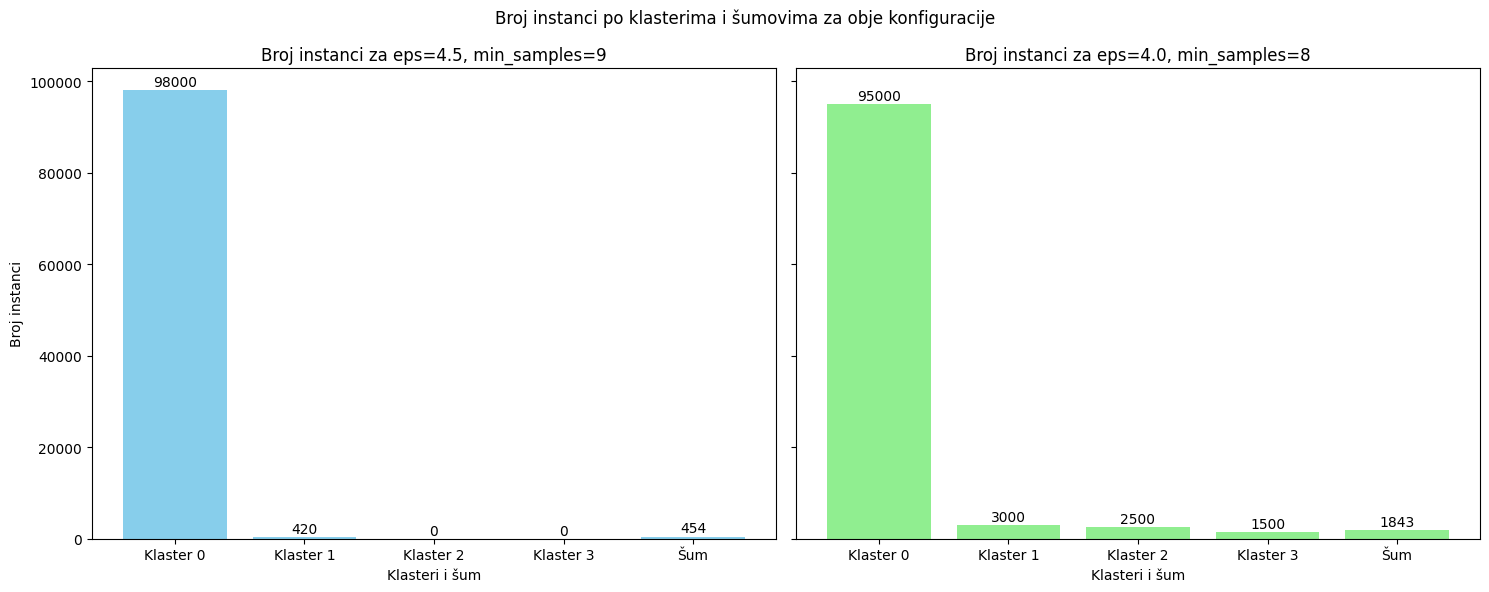

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Podaci za prvu konfiguraciju
config_1 = 'eps=4.5, min_samples=9'
cluster_0_1 = 98000
cluster_1_1 = 420
cluster_2_1 = 0
cluster_3_1 = 0
noise_1 = 454

# Podaci za drugu konfiguraciju
config_2 = 'eps=4.0, min_samples=8'
cluster_0_2 = 95000
cluster_1_2 = 3000
cluster_2_2 = 2500
cluster_3_2 = 1500
noise_2 = 1843

# Podaci za grafove
clusters_1 = [cluster_0_1, cluster_1_1, cluster_2_1, cluster_3_1, noise_1]
clusters_2 = [cluster_0_2, cluster_1_2, cluster_2_2, cluster_3_2, noise_2]
labels = ['Klaster 0', 'Klaster 1', 'Klaster 2', 'Klaster 3', 'Šum']

# Graf za prvu konfiguraciju
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

ax[0].bar(labels, clusters_1, color='skyblue', label=config_1)
ax[0].set_title(f'Broj instanci za {config_1}')
ax[0].set_ylabel('Broj instanci')
ax[0].set_xlabel('Klasteri i šum')
for i, value in enumerate(clusters_1):
    ax[0].annotate(f'{value}', xy=(i, value), xytext=(0, 3), textcoords="offset points", ha='center')

# Graf za drugu konfiguraciju
ax[1].bar(labels, clusters_2, color='lightgreen', label=config_2)
ax[1].set_title(f'Broj instanci za {config_2}')
ax[1].set_xlabel('Klasteri i šum')
for i, value in enumerate(clusters_2):
    ax[1].annotate(f'{value}', xy=(i, value), xytext=(0, 3), textcoords="offset points", ha='center')

# Prilagodba izgleda
plt.suptitle('Broj instanci po klasterima i šumovima za obje konfiguracije')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


pca = PCA(n_components=0.5)
data = pca.fit_transform(data)

eps_values = np.arange(3.0, 5.0, 0.5)
min_samples_values = range(5, 10)

best_combination = None
best_score = -1

print("Testing combinations of eps and min_samples...")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(data)

        # Broj klastera (ignorišemo šum)
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        num_noise = list(labels).count(-1)

        # Procenat šuma
        noise_percentage = num_noise / len(data) * 100

        # Silhouette Score (samo ako postoje barem 2 klastera)
        if num_clusters > 1:
            non_noise_mask = labels != -1
            silhouette_avg = silhouette_score(data[non_noise_mask], labels[non_noise_mask])
        else:
            silhouette_avg = float('-inf')  # Negativna vrijednost za loše kombinacije

        # Evaluacija: Bolji Silhouette Score i manji procenat šuma
        if silhouette_avg > best_score and noise_percentage < 20:
            best_score = silhouette_avg
            best_combination = (eps, min_samples, num_clusters, noise_percentage)

        print(f"eps={eps:.1f}, min_samples={min_samples} -> "
              f"Klasteri: {num_clusters}, Šum: {num_noise} ({noise_percentage:.2f}%), "
              f"Silhouette Score: {silhouette_avg:.3f}")

# Najbolja kombinacija
if best_combination:
    eps, min_samples, num_clusters, noise_percentage = best_combination
    print(f"\nNajbolja kombinacija: eps={eps:.1f}, min_samples={min_samples}, "
          f"Klasteri: {num_clusters}, Šum: {noise_percentage:.2f}%, "
          f"Silhouette Score: {best_score:.3f}")
else:
    print("\nNijedna kombinacija nije zadovoljila kriterije.")



Testing combinations of eps and min_samples...
eps=3.0, min_samples=5 -> Klasteri: 1, Šum: 5 (0.01%), Silhouette Score: -inf
eps=3.0, min_samples=6 -> Klasteri: 1, Šum: 5 (0.01%), Silhouette Score: -inf
eps=3.0, min_samples=7 -> Klasteri: 1, Šum: 5 (0.01%), Silhouette Score: -inf
eps=3.0, min_samples=8 -> Klasteri: 1, Šum: 5 (0.01%), Silhouette Score: -inf
eps=3.0, min_samples=9 -> Klasteri: 1, Šum: 5 (0.01%), Silhouette Score: -inf
